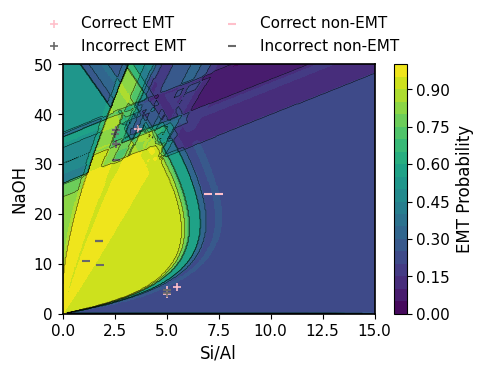

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# LOAD MODEL
# =========================
model = joblib.load('/Users/eolanrew/Desktop/Filtered_dataset/xgb_pca.pkl')

# =========================
# DATA
# =========================
df = pd.read_csv('../Filtered_dataset/Filtered_original_space.csv')

# =========================
# FEATURES
# =========================
columns_for_pca = [
    'Na', 'Al', 'Si', 'H2O',
    'Si_source_Fumed silica', 'Si_source_Ludox-AS40',
    'Si_source_Ludox-SM30', 'Si_source_Na2SiO3',
    'Si_source_TEOS', 'Pre-dissolution of Si',
    'Al_source_Al(OH)3', 'Al_source_NaAlO2',
    'Pre-dissolution of Al', 'Si/OH', 'Si/Al',
    'Time (h)', 'Temperature (°C)',
    'Si precursor sizs (nm)'
]

# =========================
# SCALER
# =========================
exclude_from_scaling = [
    'Si_source_Fumed silica', 'Si_source_Ludox-AS40',
    'Si_source_Ludox-SM30', 'Si_source_Na2SiO3',
    'Si_source_TEOS', 'Pre-dissolution of Si',
    'Al_source_Al(OH)3', 'Al_source_NaAlO2',
    'Pre-dissolution of Al'
]

columns_to_scale = [c for c in columns_for_pca if c not in exclude_from_scaling]

scaler = StandardScaler()
scaler.fit(df[columns_for_pca][columns_to_scale])

# =========================
# PCA
# =========================
X_scaled = df[columns_for_pca].copy()
X_scaled[columns_to_scale] = scaler.transform(X_scaled[columns_to_scale])

pca = PCA(n_components=3)
pca.fit(X_scaled)

# =========================
# BASE STATE (FIXED CHEMISTRY)
# =========================
base = df[columns_for_pca].mean()

Al_fixed = base["Al"]   # anchor for stoichiometry

# =========================
# GRID
# =========================
n_grid = 300

si_al_vals = np.linspace(0, 15, n_grid)   # X-axis
na_vals = np.linspace(0, 50, n_grid)      # Y-axis

XX, YY = np.meshgrid(si_al_vals, na_vals)
Z = np.zeros_like(XX)

# =========================
# MODEL LOOP
# =========================
for i in range(n_grid):
    for j in range(n_grid):

        ratio = XX[i, j]   # Si/Al
        Na = YY[i, j]

        row = base.copy()

        # -------------------------
        # STOICHIOMETRY ENFORCEMENT
        # -------------------------
        Al = Al_fixed
        Si = ratio * Al

        row["Al"] = Al
        row["Si"] = Si
        row["Na"] = Na

        row["Si/Al"] = ratio
        row["Si/OH"] = Si / Na if Na != 0 else 0

        # -------------------------
        # MODEL INPUT
        # -------------------------
        X = pd.DataFrame([row])[columns_for_pca]

        X_scaled = X.copy()
        X_scaled[columns_to_scale] = scaler.transform(X_scaled[columns_to_scale])

        X_pca = pca.transform(X_scaled)

        Z[i, j] = model.predict_proba(X_pca)[0, 1]

# =========================
# PLOT
# =========================

plt.style.use('default')

# === GLOBAL STYLE (match reference aesthetic) ===
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11
})

font_sizes = {
    "title": 14,
    "axis_labels": 12,
    "tick_labels": 11,
    "legend": 11,
    "legend_title": 12
}

# =========================
# LOAD CLASSIFICATION POINTS
# =========================
df_cls = pd.read_csv(
    '/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/Corrected/EMT_Final_average_updated.csv'
)

x_cls = df_cls["Si/Al"].values
y_cls = df_cls["Na"].values

emt = df_cls["EMT"].values
model_pred = df_cls["Model"].values

# masks
m_11 = (emt == 1) & (model_pred == 1)
m_10 = (emt == 1) & (model_pred == 0)
m_00 = (emt == 0) & (model_pred == 0)
m_01 = (emt == 0) & (model_pred == 1)

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(5, 4))

cp = ax.contourf(XX, YY, Z, levels=20, cmap="viridis")
cbar = plt.colorbar(cp)
cbar.set_label("EMT Probability", fontsize=font_sizes["axis_labels"])

ax.contour(XX, YY, Z, levels=10, colors="black", linewidths=0.3)

# =========================
# OVERLAY SCATTER POINTS
# =========================
ax.scatter(x_cls[m_11], y_cls[m_11],
           marker='+', c='pink', linewidths=1.2,
           label='Correct EMT')

ax.scatter(x_cls[m_10], y_cls[m_10],
           marker='+', c='dimgray', linewidths=1.2,
           label='Incorrect EMT')

ax.scatter(x_cls[m_00], y_cls[m_00],
           marker='_', c='pink', linewidths=1.5,
           label='Correct non-EMT')

ax.scatter(x_cls[m_01], y_cls[m_01],
           marker='_', c='dimgray', linewidths=1.5,
           label='Incorrect non-EMT')

# =========================
# AXES STYLING
# =========================
ax.set_xlabel("Si/Al", fontsize=font_sizes["axis_labels"])
ax.set_ylabel("NaOH", fontsize=font_sizes["axis_labels"])

ax.tick_params(axis='both', which='major',
               labelsize=font_sizes["tick_labels"])

ax.set_xlim(0, 15)
ax.set_ylim(0, 50)

ax.grid(False)

# optional: match clean frame style
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# =========================
# LEGEND (reference style)
# =========================
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False,
    fontsize=font_sizes["legend"],
    title_fontsize=font_sizes["legend_title"]
)

plt.tight_layout()
plt.savefig("contour.pdf", bbox_inches="tight")
plt.show()